In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
train_dir = r"C:\Users\bdivya\Downloads\train-20260131T124334Z-3-001\train"
val_dir   = r"C:\Users\bdivya\Downloads\valid-20260131T124336Z-3-001\valid"
test_dir  = r"C:\Users\bdivya\Downloads\test-20260131T124315Z-3-001\test"


In [6]:
classes = sorted(os.listdir(train_dir))
print("Classes:", classes)
print("Number of classes:", len(classes))


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [7]:
classes = sorted(os.listdir(val_dir))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [8]:
classes = sorted(os.listdir(test_dir))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [11]:
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)  # sanity check


{'glioma': 564, 'meningioma': 358, 'no_tumor': 335, 'pituitary': 438}


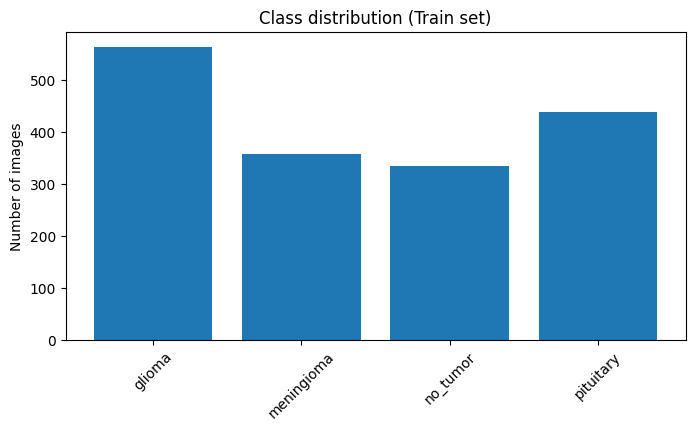

In [12]:
plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class distribution (Train set)")
plt.ylabel("Number of images")
plt.show()


In [14]:
class_counts = {}

for class_name in os.listdir(val_dir):
    class_path = os.path.join(val_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)  # sanity check

{'glioma': 161, 'meningioma': 124, 'no_tumor': 99, 'pituitary': 118}


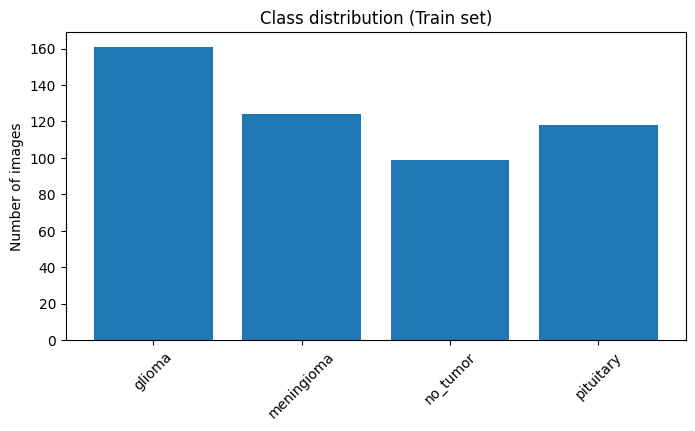

In [15]:
plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class distribution (Train set)")
plt.ylabel("Number of images")
plt.show()

In [16]:
class_counts = {}

for class_name in os.listdir(test_dir):
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print(class_counts)  # sanity check

{'glioma': 80, 'meningioma': 63, 'no_tumor': 49, 'pituitary': 54}


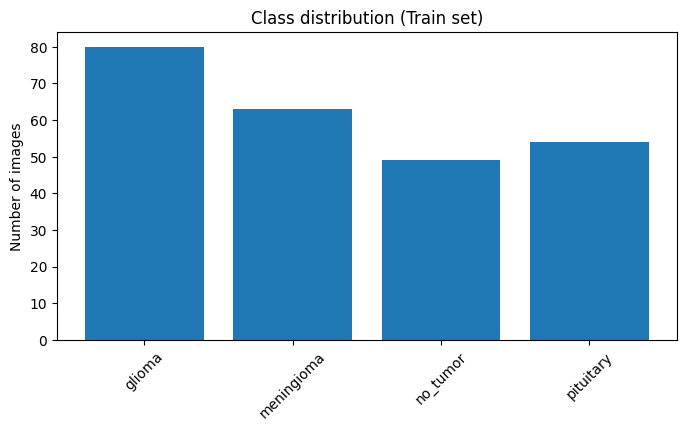

In [17]:
plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class distribution (Train set)")
plt.ylabel("Number of images")
plt.show()


In [18]:
sizes = []
channels = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    sizes.append(img.size)
    channels.append(len(img.getbands()))

sizes, channels


([(640, 640), (640, 640), (640, 640), (640, 640)], [3, 3, 3, 3])

In [19]:
sizes = []
channels = []

for cls in classes:
    cls_path = os.path.join(val_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    sizes.append(img.size)
    channels.append(len(img.getbands()))

sizes, channels

([(640, 640), (640, 640), (640, 640), (640, 640)], [3, 3, 3, 3])

In [20]:
sizes = []
channels = []

for cls in classes:
    cls_path = os.path.join(test_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    sizes.append(img.size)
    channels.append(len(img.getbands()))

sizes, channels

([(640, 640), (640, 640), (640, 640), (640, 640)], [3, 3, 3, 3])

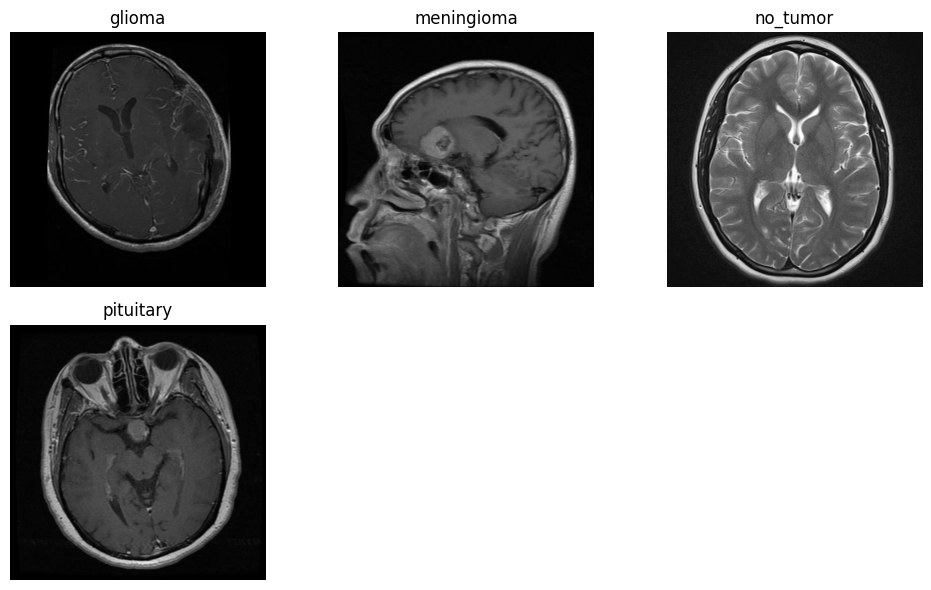

In [21]:
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(2, len(classes)//2 + 1, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()


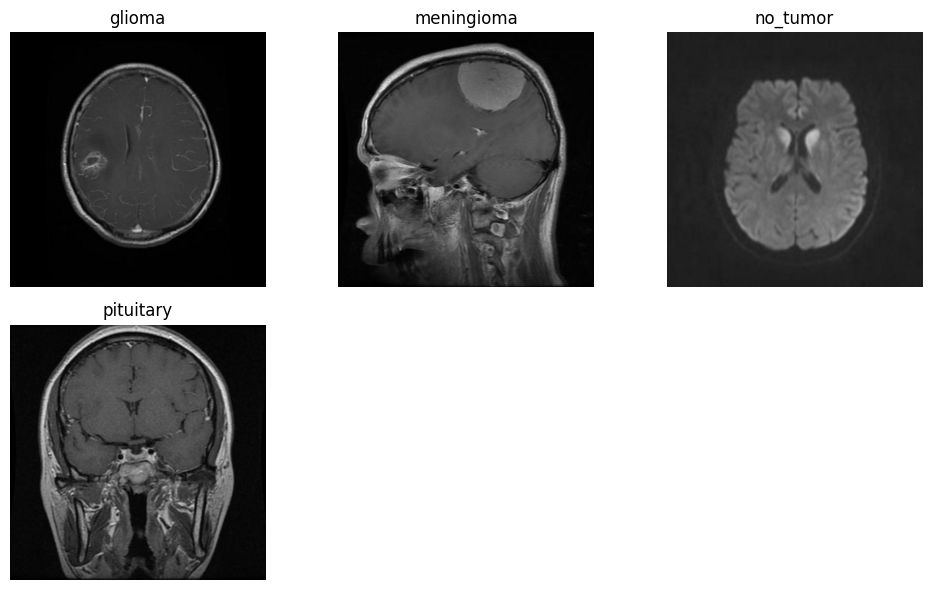

In [22]:
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(val_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(2, len(classes)//2 + 1, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

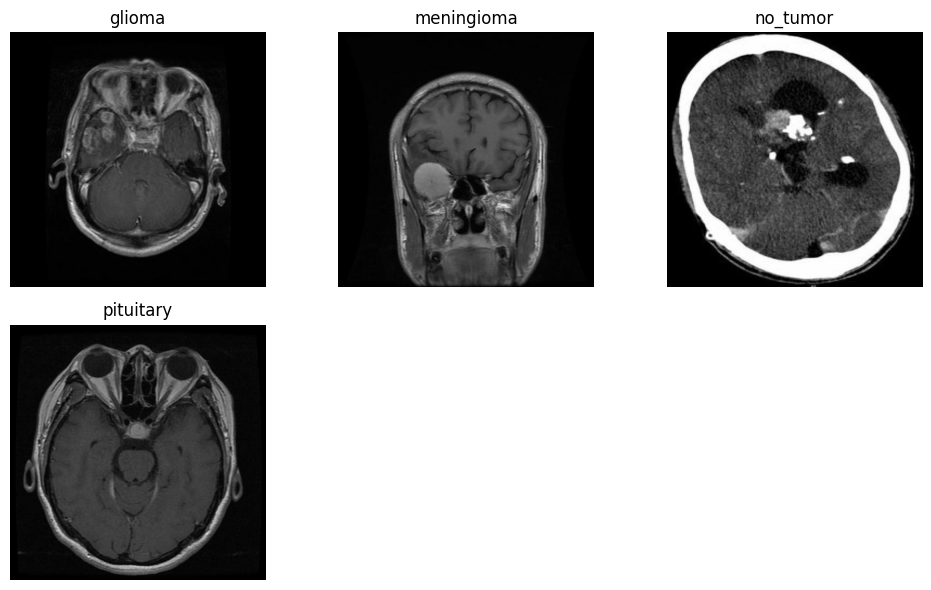

In [23]:
plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    cls_path = os.path.join(test_dir, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path)
    
    plt.subplot(2, len(classes)//2 + 1, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
!pip install torch torchvision

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
    --------------------------------------- 1.8/113.8 MB 11.8 MB/s eta 0:00:10
   - -------------------------------------- 4.7/113.8 MB 12.7 MB/s eta 0:00:09
   -- ------------------------------------- 6.3/113.8 MB 11.4 MB/s eta 0:00:10
   --- ------------------------------------ 8.7/113.8 MB 11.2 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/113.8 MB 12.0 MB/s eta 0:00:09
   ----- ---------------------------------- 14.9/113.8 MB 12.7 MB/s eta 0:00:08
   ------ --------------------------------- 18.6/113.8 MB 13.4 MB/s eta 0:00:08
   ------- -------------------------------- 22.0/113.8 MB 13.8 MB/s eta 0:00:07
   --------- ------------------------------ 25.7/113.8 MB 14.3 MB/s eta 0:00:07
   ---------- ----------------------------- 29.4/113.8 MB 14.7 MB/s eta 0:00:06
   ----------- ---------------------------- 33.6/113.8 MB 15.2 MB/s eta 0:00:06
   ------------ --------------------------- 36.4/113.

In [28]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# 1. Define transforms (with augmentation only for training)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # zoom + crop
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),   # converts pixel values to 0-1
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# 2. Load datasets with transforms
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = ImageFolder(test_dir, transform=val_test_transform)

# 3. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 4. Check output
images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)
print("Pixel range:", images.min().item(), "to", images.max().item())


Batch shape: torch.Size([32, 3, 224, 224])
Pixel range: 0.0 to 1.0


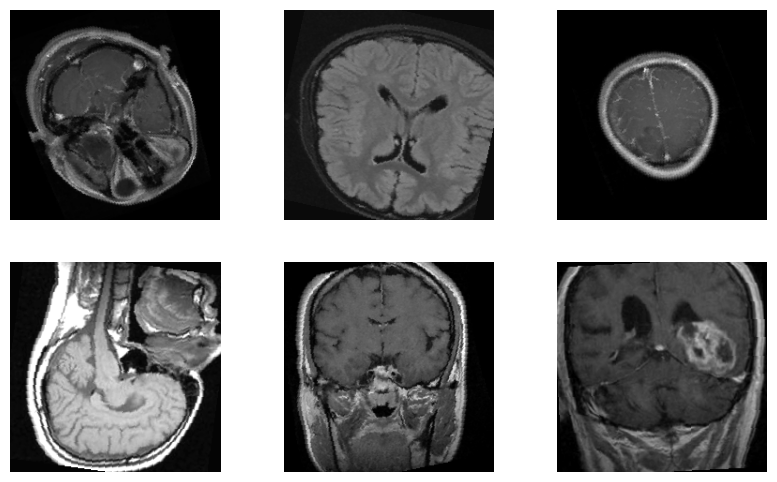

In [29]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()  # convert to HWC
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
plt.show()


In [32]:
num_classes = len(train_dataset.classes)
print(num_classes)

4


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TumorCNN(nn.Module):
    def __init__(self, num_classes):
        super(TumorCNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 14 * 14, 512),  # 224 -> /2 /2 /2 /2 = 14
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


In [33]:
model = TumorCNN(num_classes)

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset.classes)

criterion = nn.CrossEntropyLoss()


In [35]:
# Create ResNet50
model_resnet = models.resnet50(pretrained=True)
model_resnet.fc = nn.Sequential(
    nn.Linear(model_resnet.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

# Freeze pretrained layers
for param in model_resnet.parameters():
    param.requires_grad = False
for param in model_resnet.fc.parameters():
    param.requires_grad = True

model_resnet = model_resnet.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_resnet.parameters()), lr=0.001)

# Train
num_epochs = 10
for epoch in range(num_epochs):
    model_resnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"ResNet50 Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


C:\Users\bdivya\AppData\Local\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\bdivya\AppData\Local\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\bdivya/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:05<00:00, 18.2MB/s]


ResNet50 Epoch 1, Loss: 1.0094
ResNet50 Epoch 2, Loss: 0.6386
ResNet50 Epoch 3, Loss: 0.6707
ResNet50 Epoch 4, Loss: 0.5594
ResNet50 Epoch 5, Loss: 0.5075
ResNet50 Epoch 6, Loss: 0.4951
ResNet50 Epoch 7, Loss: 0.5130
ResNet50 Epoch 8, Loss: 0.4473
ResNet50 Epoch 9, Loss: 0.4642
ResNet50 Epoch 10, Loss: 0.4190


In [36]:
# Create MobileNetV2
model_mobilenet = models.mobilenet_v2(pretrained=True)
model_mobilenet.classifier[1] = nn.Sequential(
    nn.Linear(model_mobilenet.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

for param in model_mobilenet.parameters():
    param.requires_grad = False
for param in model_mobilenet.classifier.parameters():
    param.requires_grad = True

model_mobilenet = model_mobilenet.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_mobilenet.parameters()), lr=0.001)

# Train
num_epochs = 10
for epoch in range(num_epochs):
    model_mobilenet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"MobileNetV2 Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


C:\Users\bdivya\AppData\Local\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\bdivya/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|█████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:00<00:00, 17.7MB/s]


MobileNetV2 Epoch 1, Loss: 0.8776
MobileNetV2 Epoch 2, Loss: 0.6227
MobileNetV2 Epoch 3, Loss: 0.5566
MobileNetV2 Epoch 4, Loss: 0.4887
MobileNetV2 Epoch 5, Loss: 0.5084
MobileNetV2 Epoch 6, Loss: 0.4960
MobileNetV2 Epoch 7, Loss: 0.4399
MobileNetV2 Epoch 8, Loss: 0.4292
MobileNetV2 Epoch 9, Loss: 0.4057
MobileNetV2 Epoch 10, Loss: 0.4006


In [37]:
# Create EfficientNetB0
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights
import torch.nn as nn
import torch.optim as optim

# Load pretrained EfficientNetB0
model_effnet = models.efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)
model_effnet.classifier[1] = nn.Sequential(
    nn.Linear(model_effnet.classifier[1].in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

for param in model_effnet.parameters():
    param.requires_grad = False
for param in model_effnet.classifier.parameters():
    param.requires_grad = True

model_effnet = model_effnet.to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_effnet.parameters()), lr=0.001)

# Train
num_epochs = 10
for epoch in range(num_epochs):
    model_effnet.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_effnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"EfficientNetB0 Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\bdivya/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:03<00:00, 5.83MB/s]


EfficientNetB0 Epoch 1, Loss: 0.6822
EfficientNetB0 Epoch 2, Loss: 0.5121
EfficientNetB0 Epoch 3, Loss: 0.4373
EfficientNetB0 Epoch 4, Loss: 0.4084
EfficientNetB0 Epoch 5, Loss: 0.3960
EfficientNetB0 Epoch 6, Loss: 0.3757
EfficientNetB0 Epoch 7, Loss: 0.3601
EfficientNetB0 Epoch 8, Loss: 0.3550
EfficientNetB0 Epoch 9, Loss: 0.3413
EfficientNetB0 Epoch 10, Loss: 0.3110


In [38]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TumorCNN(num_classes=len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/10, Loss: 6.4452
Epoch 2/10, Loss: 1.0356
Epoch 3/10, Loss: 0.9433
Epoch 4/10, Loss: 0.9230
Epoch 5/10, Loss: 0.8621
Epoch 6/10, Loss: 0.8388
Epoch 7/10, Loss: 0.8412
Epoch 8/10, Loss: 0.8520
Epoch 9/10, Loss: 0.8450
Epoch 10/10, Loss: 0.8556


In [39]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

# Reload datasets with new size
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import inception_v3, Inception_V3_Weights

# ---- Model Creation ----
num_classes = len(train_dataset.classes)

model_inception = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1)

model_inception.fc = nn.Sequential(
    nn.Linear(model_inception.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

# ---- Freeze pretrained layers ----
for param in model_inception.parameters():
    param.requires_grad = False

# ---- Unfreeze classifier only ----
for param in model_inception.fc.parameters():
    param.requires_grad = True

# ---- Move model to device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_inception = model_inception.to(device)

# ---- Optimizer & Loss ----
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_inception.parameters()), lr=0.001)

# ---- Training ----
num_epochs = 10

for epoch in range(num_epochs):
    model_inception.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_inception(images)

        # If aux_logits=True, output is tuple (main, aux)
        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"InceptionV3 Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\bdivya/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth


100%|███████████████████████████████████████████████████████████████████████████████| 104M/104M [00:08<00:00, 12.2MB/s]


InceptionV3 Epoch 1, Loss: 0.9716
InceptionV3 Epoch 2, Loss: 0.5639
InceptionV3 Epoch 3, Loss: 0.5154
InceptionV3 Epoch 4, Loss: 0.4992
InceptionV3 Epoch 5, Loss: 0.4510
InceptionV3 Epoch 6, Loss: 0.4297
InceptionV3 Epoch 7, Loss: 0.4304
InceptionV3 Epoch 8, Loss: 0.4201
InceptionV3 Epoch 9, Loss: 0.3780
InceptionV3 Epoch 10, Loss: 0.3925


In [47]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, test_loader, device):
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for images, target in test_loader:
            images, target = images.to(device), target.to(device)
            outputs = model(images)

            # for inception model output tuple
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(target.cpu().numpy())

    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average='weighted')
    rec = recall_score(labels, preds, average='weighted')
    f1 = f1_score(labels, preds, average='weighted')
    cm = confusion_matrix(labels, preds)

    return acc, prec, rec, f1, cm


In [49]:
from torchvision import transforms

train_transform_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transform_299 = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Reload datasets with new size
train_dataset_299 = ImageFolder(train_dir, transform=train_transform_299)
val_dataset_299   = ImageFolder(val_dir, transform=val_test_transform_299)
test_dataset_299  = ImageFolder(test_dir, transform=val_test_transform_299)
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset   = ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = ImageFolder(test_dir, transform=val_test_transform)

train_loader_299 = DataLoader(train_dataset_299, batch_size=32, shuffle=True)
val_loader_299   = DataLoader(val_dataset_299, batch_size=32, shuffle=False)
test_loader_299  = DataLoader(test_dataset_299, batch_size=32, shuffle=False)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [50]:
models = {
    "Custom CNN": model,
    "ResNet50": model_resnet,
    "MobileNetV2": model_mobilenet,
    "EfficientNetB0": model_effnet,
    "InceptionV3": model_inception
}

results = {}

for name, m in models.items():
    # Use test_loader_299 only for InceptionV3
    if name == "InceptionV3":
        acc, prec, rec, f1, cm = evaluate_model(m, test_loader_299, device)
    else:
        acc, prec, rec, f1, cm = evaluate_model(m, test_loader, device)

    results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Confusion Matrix": cm
    }

# Print results
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall: {metrics['Recall']:.4f}")
    print(f"F1 Score: {metrics['F1-Score']:.4f}")
    print(metrics["Confusion Matrix"])




Custom CNN:
Accuracy: 0.7114
Precision: 0.7250
Recall: 0.7114
F1 Score: 0.6779
[[79  0  1  0]
 [30 16 15  2]
 [ 3  5 36  5]
 [ 8  1  1 44]]

ResNet50:
Accuracy: 0.8537
Precision: 0.8577
Recall: 0.8537
F1 Score: 0.8533
[[75  5  0  0]
 [ 8 49  3  3]
 [ 1 10 37  1]
 [ 3  2  0 49]]

MobileNetV2:
Accuracy: 0.7683
Precision: 0.7834
Recall: 0.7683
F1 Score: 0.7658
[[77  3  0  0]
 [18 38  5  2]
 [ 7  8 34  0]
 [ 3 11  0 40]]

EfficientNetB0:
Accuracy: 0.8821
Precision: 0.8860
Recall: 0.8821
F1 Score: 0.8820
[[75  5  0  0]
 [ 5 54  3  1]
 [ 1  2 45  1]
 [ 4  6  1 43]]

InceptionV3:
Accuracy: 0.8577
Precision: 0.8644
Recall: 0.8577
F1 Score: 0.8562
[[69  8  1  2]
 [ 3 45  4 11]
 [ 2  1 43  3]
 [ 0  0  0 54]]


In [51]:
import pandas as pd

summary = []
for name, m in results.items():
    summary.append([name,
                    m["Accuracy"],
                    m["Precision"],
                    m["Recall"],
                    m["F1-Score"]])

df = pd.DataFrame(summary, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
df = df.sort_values(by="Accuracy", ascending=False)
df


,Model,Accuracy,Precision,Recall,F1
3,EfficientNetB0,0.882114,0.886034,0.882114,0.882011
4,InceptionV3,0.857724,0.864421,0.857724,0.856201
1,ResNet50,0.853659,0.857674,0.853659,0.853318
2,MobileNetV2,0.768293,0.783387,0.768293,0.765793
0,Custom CNN,0.711382,0.725025,0.711382,0.677898


In [52]:
import h5py
import torch

def save_model_h5(model, filename):
    state_dict = model.state_dict()
    with h5py.File(filename, 'w') as f:
        for key, value in state_dict.items():
            f.create_dataset(key, data=value.cpu().numpy())


In [53]:
save_model_h5(model, "custom_cnn.h5")
save_model_h5(model_resnet, "resnet50.h5")
save_model_h5(model_mobilenet, "mobilenetv2.h5")
save_model_h5(model_effnet, "efficientnetb0.h5")   # BEST MODEL
save_model_h5(model_inception, "inceptionv3.h5")


In [55]:
import h5py
import torch
from efficientnet_pytorch import EfficientNet

# Load model
model = EfficientNet.from_pretrained('efficientnet-b0')

# Load weights
state_dict = {}
with h5py.File("efficientnetb0.h5", "r") as f:
    for k in f.keys():
        state_dict[k] = torch.tensor(f[k][()])

print(model.classifier)
print([k for k in state_dict.keys() if "classifier" in k])


ModuleNotFoundError: No module named 'efficientnet_pytorch'